In [ ]:
import yfinance as yf
from datetime import datetime

# Get the stock quote for Apple using yfinance
df = yf.download('AMZN', start='2014-10-29', end=datetime.now())

# Display the data
print(df)

[*********************100%***********************]  1 of 1 completed

Price                       Adj Close       Close        High         Low  \
Ticker                           AMZN        AMZN        AMZN        AMZN   
Date                                                                        
2014-10-29 00:00:00+00:00   14.706000   14.706000   14.980500   14.653500   
2014-10-30 00:00:00+00:00   14.953500   14.953500   14.987000   14.618000   
2014-10-31 00:00:00+00:00   15.273000   15.273000   15.286000   15.075000   
2014-11-03 00:00:00+00:00   15.286000   15.286000   15.400500   15.162000   
2014-11-04 00:00:00+00:00   15.140500   15.140500   15.212500   15.008500   
...                               ...         ...         ...         ...   
2024-11-27 00:00:00+00:00  205.740005  205.740005  207.639999  205.050003   
2024-11-29 00:00:00+00:00  207.889999  207.889999  208.199997  204.589996   
2024-12-02 00:00:00+00:00  210.710007  210.710007  212.990005  209.509995   
2024-12-03 00:00:00+00:00  213.440002  213.440002  214.020004  209.649994   

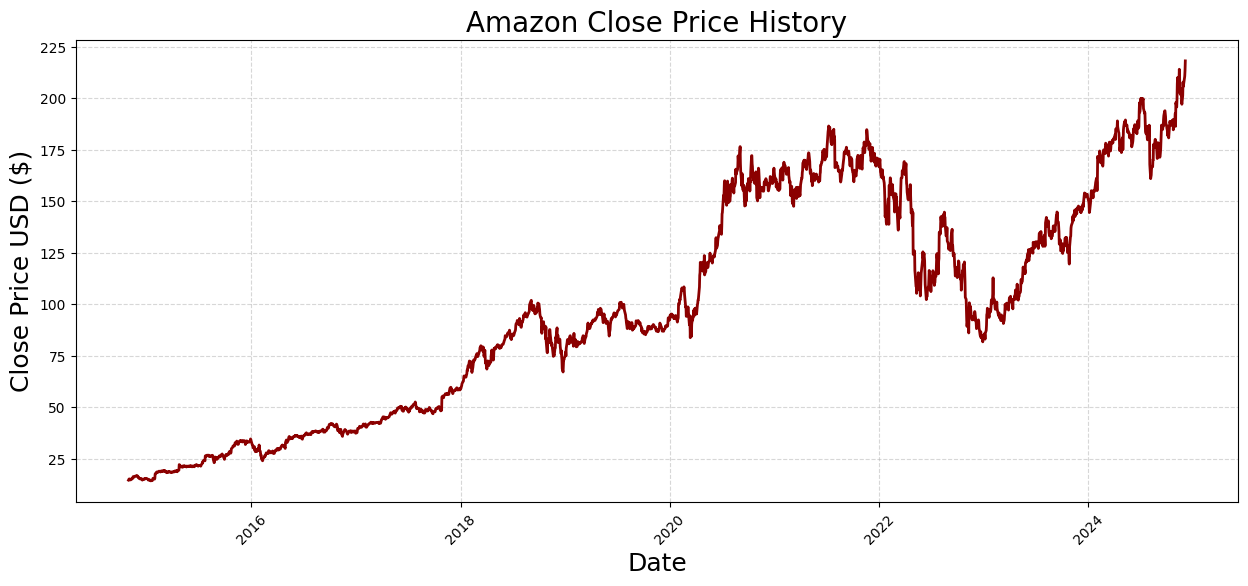

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.title('Amazon Close Price History', fontsize=20)
plt.plot(df['Close'], color='darkred', linewidth=2)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
import numpy as np  # Importing numpy if not already done

# Create a new dataframe with only the 'Close' column
data = df.filter(['Close'])

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

training_data_len

2415

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

# Ensure 'Close' column exists, if not, try 'close'
if 'Close' in df.columns:
    data = df[['Close']]  # Using double brackets to ensure a DataFrame is created
else:
    data = df[['close']]  # Trying 'close' as the column name

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00175897],
       [0.00297332],
       [0.00454094],
       ...,
       [0.96344681],
       [0.97684145],
       [1.        ]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.00175897, 0.00297332, 0.00454094, 0.00460472, 0.00389083,
       0.00234775, 0.00237718, 0.00316713, 0.00445508, 0.00614781,
       0.00602514, 0.00724441, 0.01002638, 0.00885618, 0.00931739,
       0.00971236, 0.01069365, 0.01120638, 0.0119448 , 0.01179761,
       0.01143698, 0.01268077, 0.00957988, 0.00965594, 0.00724931,
       0.0073548 , 0.00629991, 0.00483042, 0.00626802, 0.00463416,
       0.00500705, 0.00499724, 0.00469059, 0.00198958, 0.00292671,
       0.00264459, 0.00317694, 0.00480589, 0.00474456, 0.0039448 ,
       0.00543146, 0.00615517, 0.00572831, 0.00574057, 0.00529163,
       0.00373873, 0.002046  , 0.00281386, 0.00331432, 0.00244833,
       0.00109415, 0.00191107, 0.00155044, 0.        , 0.00092978,
       0.00061086, 0.00252683, 0.00573321, 0.00624103, 0.0055713 ])]
[0.004857404489855319]

[array([0.00175897, 0.00297332, 0.00454094, 0.00460472, 0.00389083,
       0.00234775, 0.00237718, 0.00316713, 0.00445508, 0.00614781,
       0.00602514, 0.00724441, 0.0

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2355/2355 ━━━━━━━━━━━━━━━━━━━━ 138s 57ms/step - loss: 0.0045


In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step


6.907085051125368

<ipython-input-8-0cdd5e68a3a9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


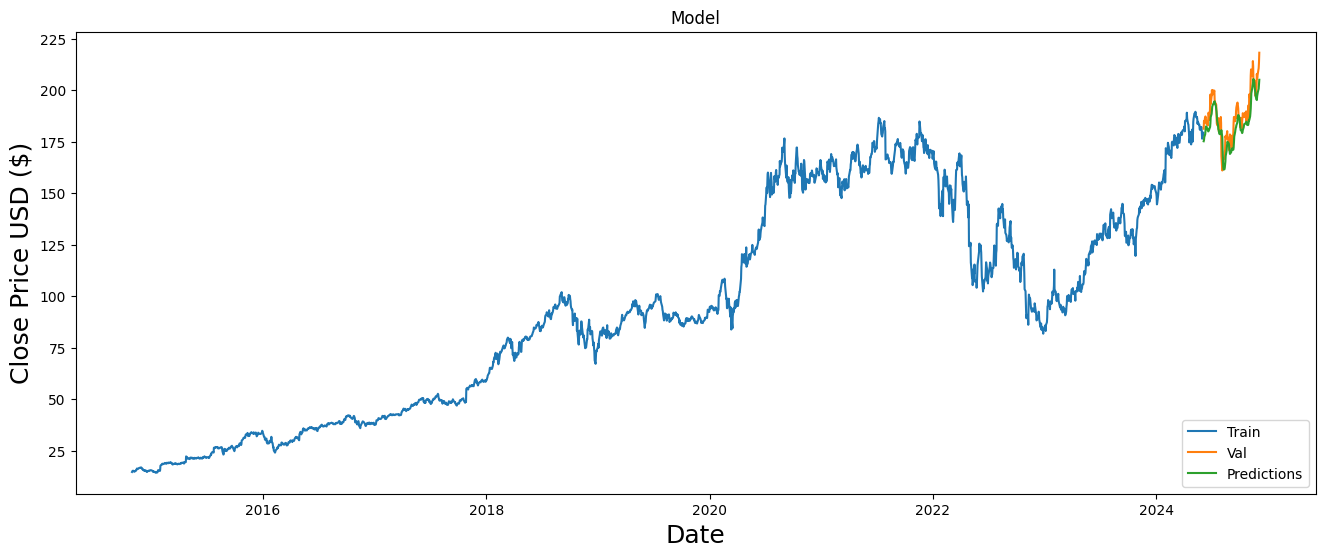

In [ ]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
# Show the valid and predicted prices
valid

Price,Close,Predictions
Ticker,AMZN,
Date,,
2024-06-05 00:00:00+00:00,181.279999,175.193329
2024-06-06 00:00:00+00:00,185.000000,175.693054
2024-06-07 00:00:00+00:00,184.300003,177.215546
2024-06-10 00:00:00+00:00,187.059998,178.599609
2024-06-11 00:00:00+00:00,187.229996,180.246262
...,...,...
2024-11-27 00:00:00+00:00,205.740005,197.076447
2024-11-29 00:00:00+00:00,207.889999,198.837234


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # RMSE is the square root of MSE

# Display the metrics
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Evaluation Metrics:
Mean Absolute Error (MAE): 5.719635250061516
Mean Squared Error (MSE): 47.707823903479536
Root Mean Squared Error (RMSE): 6.907085051125368
